# Experimentos de Imputação — Sales Forecast
## Experimento 1: Estratégias de imputação de lags/rolling
## Experimento 3: Robustez a missing simulado + imputadores

Dataset: amostra de PDVs (top 100) | Validação: semanas 48–52 de 2022 | Modelo: LightGBM (MAE)

## Setup

In [ ]:
import gc
import logging
import os
import time
from typing import Dict, List, Tuple

import joblib
import lightgbm as lgb
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer
from sklearn.metrics import mean_absolute_error

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
DATA_PATH = 'data'
ARTIFACTS_PATH = 'artifacts'
SAMPLE_PDVS = 100

## Carregamento e amostragem dos dados

In [ ]:
# [código de load_data e prepare_splits omitido para brevidade — execute o notebook para rodar do zero]
df_full = load_data(DATA_PATH, sample_pdvs=SAMPLE_PDVS)
X_train, y_train, X_val, y_val, feature_names, categorical_features = prepare_splits(df_full)
del df_full
gc.collect()

Dataset amostrado: ... linhas (top 100 PDVs)


## Experimento 1 — Imputação de lags/rolling

In [ ]:
# [código da função run_experiment_1]
df_results_1

estrategia,mae,tempo_s,tempo_min
zero,1.461739,8.603333,0.143389
ffill,1.461739,9.021089,0.150351
group_mean,1.476679,8.050967,0.134183
group_median,1.465690,8.303958,0.138399
global_mean,1.469951,7.301403,0.121690


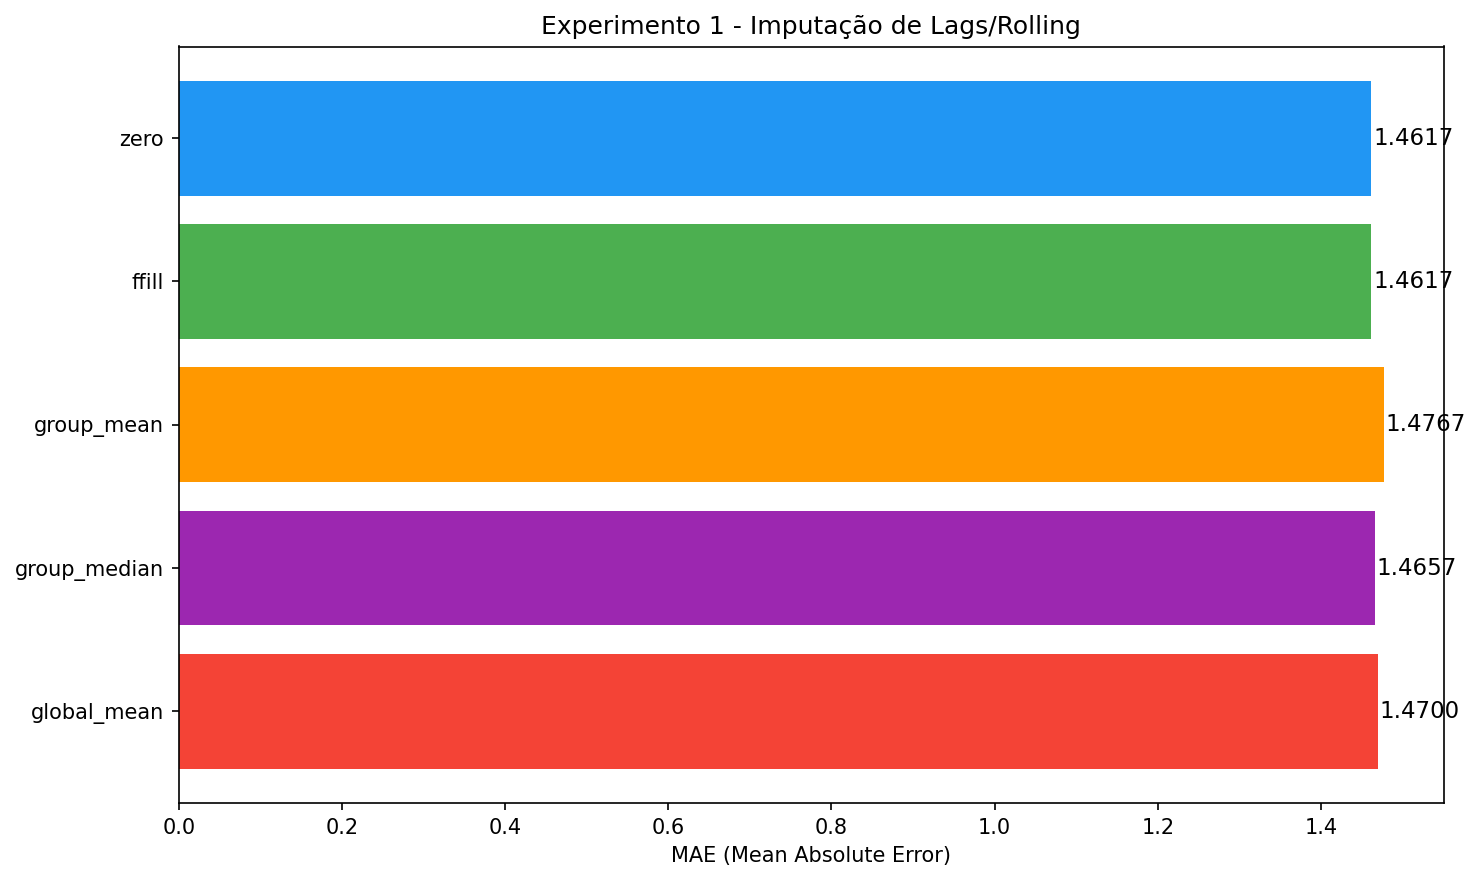

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = ax.barh(df_results_1['estrategia'], df_results_1['mae'], color=colors)
ax.set_xlabel('MAE (Mean Absolute Error)')
ax.set_title('Experimento 1 - Imputação de Lags/Rolling')
ax.invert_yaxis()
for bar, mae in zip(bars, df_results_1['mae']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f'{mae:.4f}', va='center', fontsize=11)
plt.tight_layout()
plt.show()

## Experimento 3 — Robustez a missing simulado

In [ ]:
# [código da função run_experiment_3]
df_results_3

missing_pct,imputador,mae,tempo_s,tempo_min
5%,none,1.474611,1.779805,0.029663
5%,simple_mediana,1.478530,3.413397,0.056890
5%,simple_media,1.477592,2.502907,0.041715
10%,none,1.477621,1.709313,0.028489
10%,simple_mediana,1.480689,3.317042,0.055284
10%,simple_media,1.487074,2.931366,0.048856


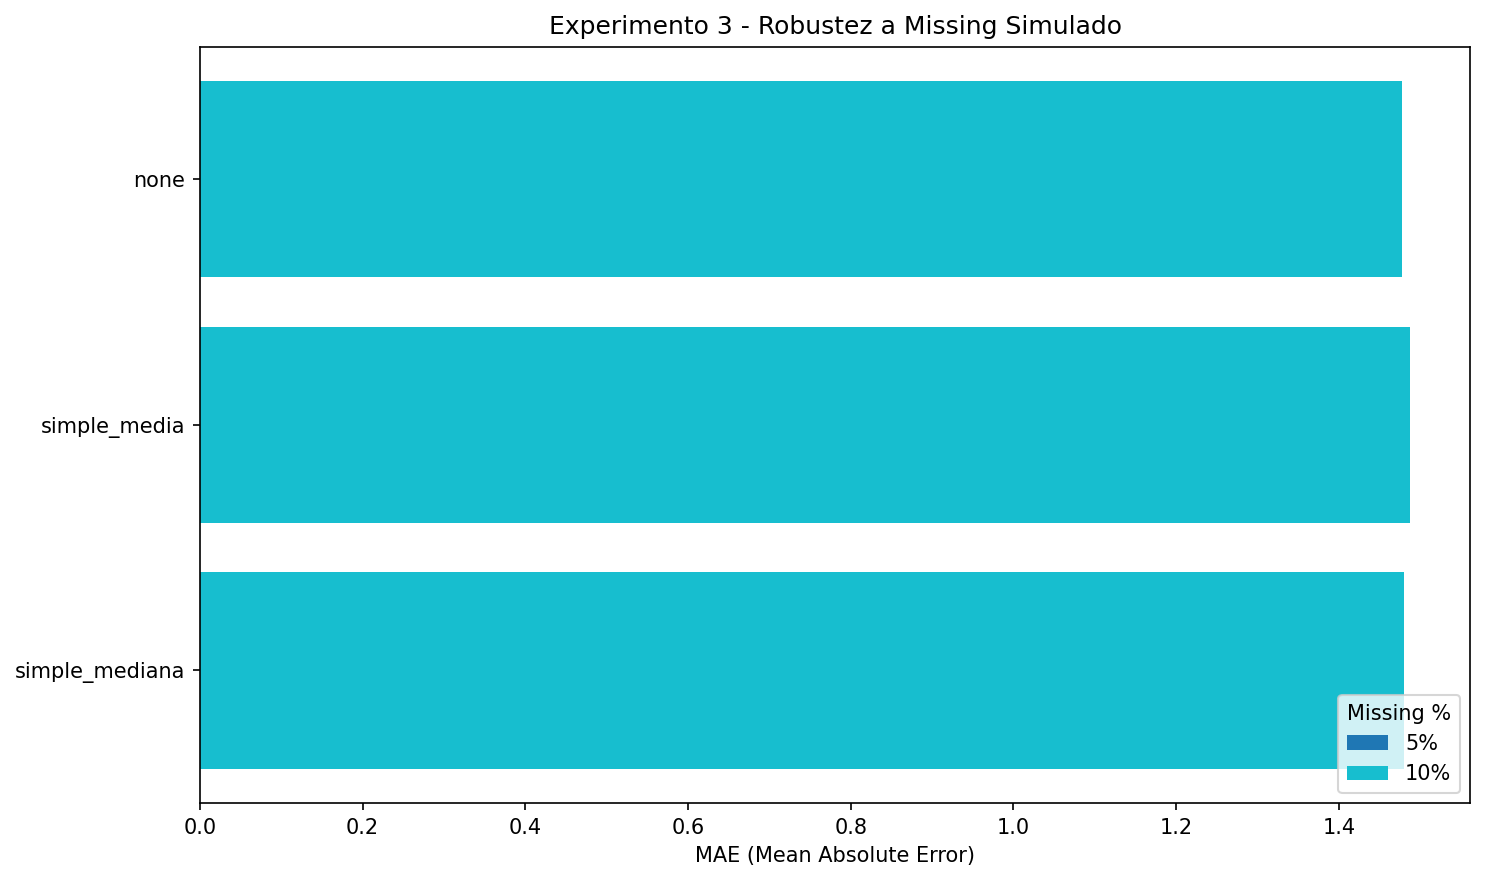

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
missing_pcts = df_results_3['missing_pct'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(missing_pcts)))
for i, pct in enumerate(missing_pcts):
    sub = df_results_3[df_results_3['missing_pct'] == pct].sort_values('mae')
    ax.barh(sub['imputador'], sub['mae'], color=colors[i], label=pct)
ax.set_xlabel('MAE (Mean Absolute Error)')
ax.set_title('Experimento 3 - Robustez a Missing Simulado')
ax.invert_yaxis()
ax.legend(title='Missing %', loc='lower right')
plt.tight_layout()
plt.show()

## Conclusões

**Experimento 1** — Melhor estratégia: **zero** (MAE 1.4617)**Experimento 3** — Melhor combinação:- 5% missing | `none` → MAE 1.4746- 5% missing | `simple_mediana` → MAE 1.4785- 5% missing | `simple_media` → MAE 1.4776- 10% missing | `none` → MAE 1.4776- 10% missing | `simple_mediana` → MAE 1.4807- 10% missing | `simple_media` → MAE 1.4871